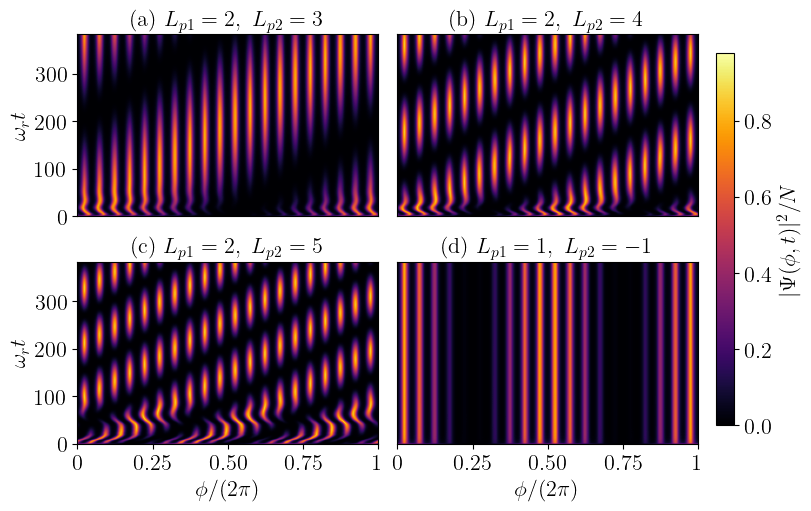

In [1]:
import numpy as np
import matplotlib.pyplot as plt

save_file = r"Figure_20_data.npz"
data = np.load(save_file, allow_pickle=True)

density_all = data["density_all"]
L1_list = data["L1_list"]
L2_list = data["L2_list"]

t_eval = data["t_eval"]
omega_r = data["omega_r"]
N = data["N"]

cases = list(zip(L1_list, L2_list))
labels = ['(a)', '(b)', '(c)', '(d)']

import matplotlib.pyplot as plt

# ================== LaTeX / journal style ==================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.facecolor": "white"
})

LABEL_SIZE = 16
TICK_SIZE  = 16
TITLE_SIZE = 16
CBAR_LABEL = 16
CBAR_TICK  = 16

# ================== Figure ==================
fig, axes = plt.subplots(2, 2, figsize=(8, 5), constrained_layout=True)
axes = axes.flatten()

# ================== Plot ==================
for i, ax in enumerate(axes):

    density_mod = density_all[i]

    im = ax.imshow(
        density_mod / N,
        extent=[0, 1, t_eval[0]*omega_r, t_eval[-1]*omega_r],
        aspect='auto',
        cmap='inferno',
        origin='lower'
    )

    L1, L2 = cases[i]

    ax.set_title(
        rf"{labels[i]} $L_{{p1}}={L1},\ L_{{p2}}={L2}$",
        fontsize=TITLE_SIZE
    )

    # ---- x-axis formatting
    if i < 2:
        ax.set_xticks([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel(r"$\phi/(2\pi)$", fontsize=LABEL_SIZE)
        ax.set_xticks([0, 0.25, 0.50, 0.75, 1])
        ax.set_xticklabels([r"$0$", r"$0.25$", r"$0.50$", r"$0.75$", r"$1$"], fontsize=TICK_SIZE)

    # ---- y-axis formatting
    if i % 2 == 0:
        ax.set_ylabel(r"$\omega_r t$", fontsize=LABEL_SIZE)
    else:
        ax.set_yticks([])

    ax.tick_params(axis='both', labelsize=TICK_SIZE)

# ================== Colorbar ==================
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)

cbar.set_label(r"$|\Psi(\phi,t)|^2/N$", fontsize=CBAR_LABEL)
cbar.ax.tick_params(labelsize=CBAR_TICK)

plt.show()